In [37]:
import pandas as pd
df = pd.read_csv("/home/thinkpad/Documents/BrototypeStudying/paper_three/module10/data/student_result_practice.csv")
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        100 non-null    int64  
 1   gender            100 non-null    str    
 2   school_type       100 non-null    str    
 3   parent_education  96 non-null     str    
 4   study_hours       95 non-null     float64
 5   attendance_pct    96 non-null     float64
 6   previous_score    95 non-null     float64
 7   sleep_hours       97 non-null     float64
 8   has_tutor         100 non-null    str    
 9   internet_access   100 non-null    str    
 10  result            100 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 8.7 KB


In [39]:
df.shape

(100, 11)

In [40]:
df.duplicated().sum()

np.int64(4)

In [41]:
df = df.drop_duplicates()

In [42]:
df.isnull().sum()

student_id          0
gender              0
school_type         0
parent_education    4
study_hours         5
attendance_pct      4
previous_score      5
sleep_hours         3
has_tutor           0
internet_access     0
result              0
dtype: int64

In [43]:
df.head(5)

,student_id,gender,school_type,parent_education,study_hours,attendance_pct,previous_score,sleep_hours,has_tutor,internet_access,result
0,267,M,Private,Graduate,NaN,79.0,58.0,7.7,No,Yes,Pass
1,233,M,Private,Graduate,2.4,56.0,62.0,5.5,No,Yes,Fail
2,247,Female,government,Graduate,2.0,74.0,49.0,6.9,No,Yes,Fail
3,229,Female,Aided,Postgraduate,3.3,96.0,70.0,5.7,Yes,Yes,Pass
4,275,Male,Private,NaN,4.7,81.0,47.0,7.3,Yes,Yes,Pass


In [44]:
df["internet_access"].value_counts()

internet_access
Yes    81
No     15
Name: count, dtype: int64

In [45]:
df.groupby("result")["internet_access"].count()

result
Fail    34
Pass    62
Name: internet_access, dtype: int64

In [46]:
pd.crosstab(df["internet_access"], df["result"], normalize="index") * 100

result,Fail,Pass
internet_access,,
No,33.333333,66.666667
Yes,35.802469,64.197531


<Axes: xlabel='internet_access', ylabel='count'>

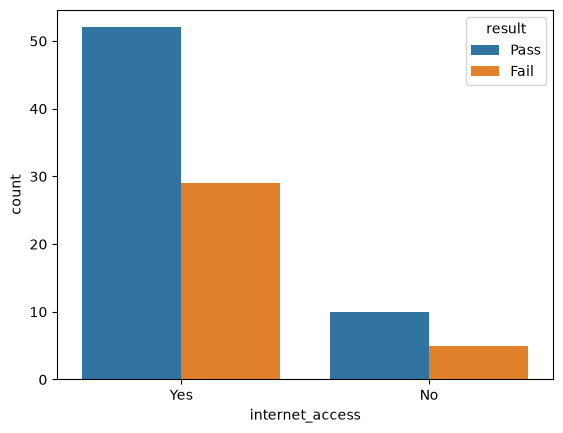

In [47]:
sns.countplot(data=df, x="internet_access", hue="result")

In [54]:
df["gender"].value_counts()

gender
male      50
female    46
Name: count, dtype: int64

In [49]:
gender_map = {
    "m" : "male",
    "f" : "female"
}

In [50]:
df["gender"] = df["gender"].str.strip().str.lower()

In [53]:
df["gender"] = df["gender"].replace(gender_map)

In [60]:
pd.crosstab(df["gender"], df["result"], normalize="index")*100

result,Fail,Pass
gender,,
female,26.086957,73.913043
male,44.000000,56.000000


In [ ]:
matrix_corr = df.corr(numeric_only=True)

,student_id,study_hours,attendance_pct,previous_score,sleep_hours
student_id,1.000000,0.061055,-0.026267,0.093478,0.122788
study_hours,0.061055,1.000000,0.011941,-0.106696,0.004807
attendance_pct,-0.026267,0.011941,1.000000,0.105392,-0.012555
previous_score,0.093478,-0.106696,0.105392,1.000000,0.019358
sleep_hours,0.122788,0.004807,-0.012555,0.019358,1.000000


In [62]:
# sns.pairplot(df, vars=["study_hours", "attendance_pct", "previous_score", "sleep_hours"],
#              hue="result")

<Axes: xlabel='study_hours', ylabel='attendance_pct'>

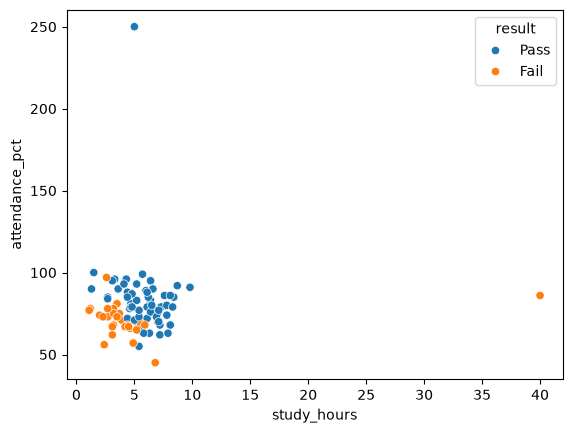

In [63]:
sns.scatterplot(data=df, x="study_hours", y="attendance_pct", hue="result")

<Axes: xlabel='has_tutor', ylabel='study_hours'>

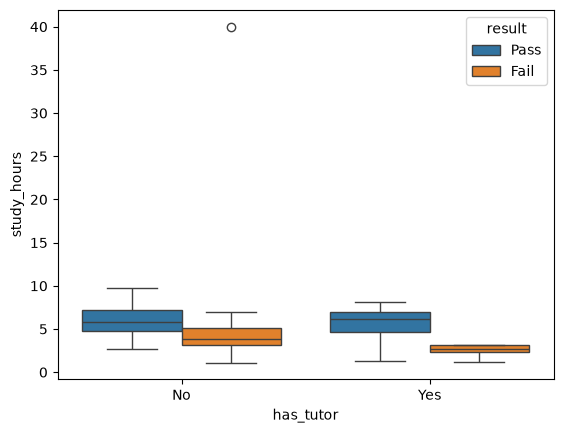

In [65]:
sns.boxplot(data=df, x="has_tutor", y="study_hours", hue="result")

In [66]:
df.head(5)

,student_id,gender,school_type,parent_education,study_hours,attendance_pct,previous_score,sleep_hours,has_tutor,internet_access,result
0,267,male,Private,Graduate,NaN,79.0,58.0,7.7,No,Yes,Pass
1,233,male,Private,Graduate,2.4,56.0,62.0,5.5,No,Yes,Fail
2,247,female,government,Graduate,2.0,74.0,49.0,6.9,No,Yes,Fail
3,229,female,Aided,Postgraduate,3.3,96.0,70.0,5.7,Yes,Yes,Pass
4,275,male,Private,NaN,4.7,81.0,47.0,7.3,Yes,Yes,Pass


In [69]:
df["school_type"].value_counts()

school_type
private       45
government    35
aided         16
Name: count, dtype: int64

In [68]:
df["school_type"] = df["school_type"].str.strip().str.lower()

In [72]:
pd.crosstab(df["school_type"], df["result"], normalize="index")*100

result,Fail,Pass
school_type,,
aided,25.000000,75.000000
government,37.142857,62.857143
private,37.777778,62.222222
